In [1]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from xgboost.callback import EarlyStopping
import matplotlib.pyplot as plt
import warnings

warnings.simplefilter(action='ignore', category=Warning)
RANDOM_STATE = 55

## Preparing Data

In [2]:
df = pd.read_csv('heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [4]:
cat_variables = df.select_dtypes(include='object').columns
cat_variables

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')

In [5]:
df = pd.get_dummies(data=df, prefix=cat_variables, columns=cat_variables)

In [6]:
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138,214,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150,195,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


In [7]:
var = [x for x in df.columns if x not in ['HeartDisease']]

In [8]:
len(var)

20

In [9]:
X_train, X_test, y_train, y_test = train_test_split(df[var], df['HeartDisease'], test_size= 0.2, random_state=RANDOM_STATE)

In [10]:
print(f'train samples: {len(X_train)}\ntest samples: {len(X_test)}')
print(f'train target proportion: {sum(y_train)/len(y_train):.4f}')
print(f'test target proportion: {sum(y_test)/len(y_test):.4f}')

train samples: 734
test samples: 184
train target proportion: 0.5518
test target proportion: 0.5598


## Building Models
### Decision Tree

In [11]:
min_samples_list = [2, 10, 30, 50, 100, 200, 300, 700]
max_depth_list = [1, 2, 3, 4, 8, 16, 32, 64, None]

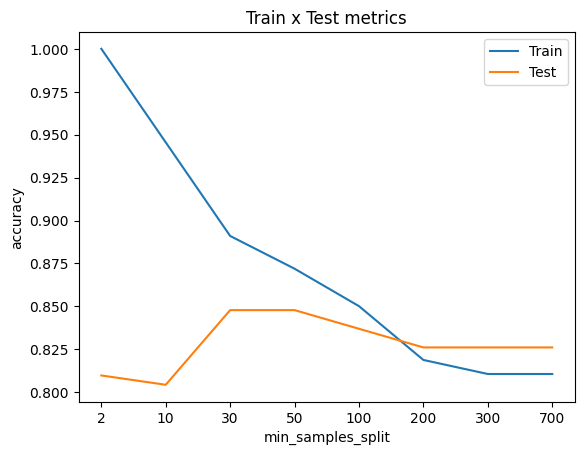

In [12]:
accuracy_list_train = []
accuracy_list_test = []

for min_samples_split in min_samples_list:
    model = DecisionTreeClassifier(min_samples_split=min_samples_split,
                                  random_state=RANDOM_STATE).fit(X_train, y_train)
    predictions_train = model.predict(X_train)
    predictions_test = model.predict(X_test)
    accuracy_list_train.append(accuracy_score(predictions_train, y_train))
    accuracy_list_test.append(accuracy_score(predictions_test, y_test))

plt.title('Train x Test metrics')
plt.xlabel('min_samples_split')
plt.ylabel('accuracy')
plt.xticks(ticks= range(len(min_samples_list)), labels=min_samples_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_test)
plt.legend(['Train', 'Test'])

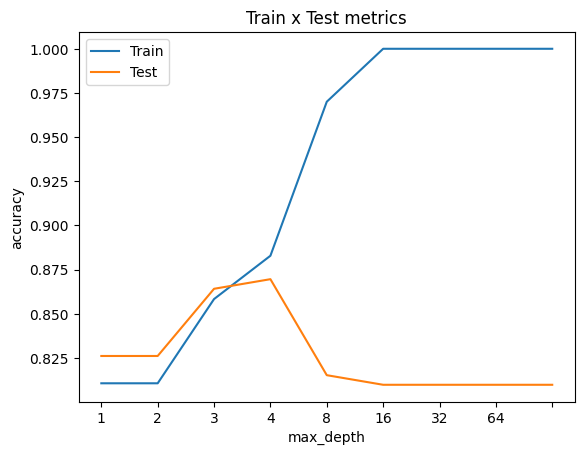

In [13]:
accuracy_list_train = []
accuracy_list_test = []

for max_depth in max_depth_list:
    model = DecisionTreeClassifier(max_depth=max_depth, random_state=RANDOM_STATE).fit(X_train, y_train)
    predictions_train = model.predict(X_train)
    predictions_test = model.predict(X_test)
    accuracy_list_train.append(accuracy_score(predictions_train, y_train))
    accuracy_list_test.append(accuracy_score(predictions_test, y_test))

plt.title('Train x Test metrics')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.xticks(ticks=range(len(max_depth_list)), labels=max_depth_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_test)
plt.legend(['Train', 'Test'])

In [14]:
decision_tree_model = DecisionTreeClassifier(min_samples_split=50, max_depth=3,
                                             random_state=RANDOM_STATE).fit(X_train, y_train)
print("Accuracy score on train: ", accuracy_score(decision_tree_model.predict(X_train), y_train))
print("Accuracy score on test: ", accuracy_score(decision_tree_model.predict(X_test), y_test))

Accuracy score on train:  0.8583106267029973
Accuracy score on test:  0.8641304347826086


### Random Forest

In [15]:
min_samples_split_list = [2,10, 30, 50, 100, 200, 300, 700]  ## If the number is an integer, then it is the actual quantity of samples,
                                             ## If it is a float, then it is the percentage of the dataset
max_depth_list = [2, 4, 8, 16, 32, 64, None]
n_estimators_list = [10,50,100,500]

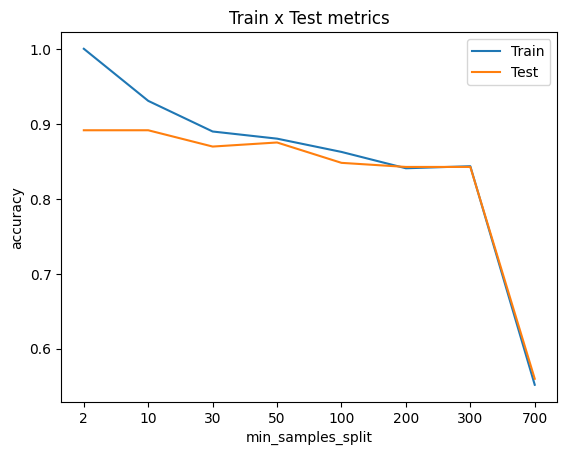

In [16]:
accuracy_list_train = []
accuracy_list_test = []
for min_samples_split in min_samples_split_list:
    model = RandomForestClassifier(min_samples_split = min_samples_split,
                                   random_state = RANDOM_STATE).fit(X_train,y_train) 
    predictions_train = model.predict(X_train) 
    predictions_test = model.predict(X_test) 
    accuracy_list_train.append(accuracy_score(predictions_train,y_train))
    accuracy_list_test.append(accuracy_score(predictions_test,y_test))

plt.title('Train x Test metrics')
plt.xlabel('min_samples_split')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(min_samples_split_list )),labels=min_samples_split_list) 
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_test)
plt.legend(['Train','Test'])

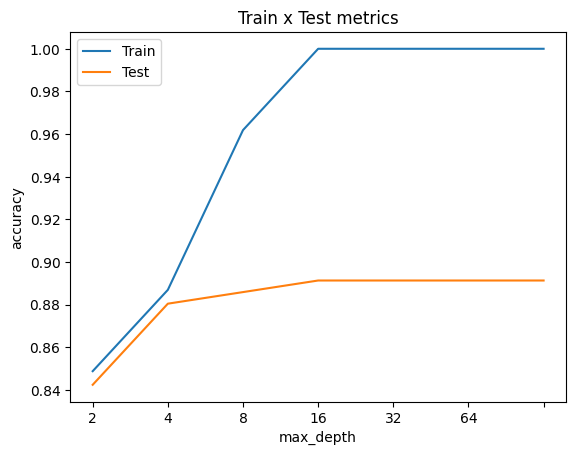

In [17]:
accuracy_list_train = []
accuracy_list_test = []
for max_depth in max_depth_list:
    model = RandomForestClassifier(max_depth = max_depth,
                                   random_state = RANDOM_STATE).fit(X_train,y_train) 
    predictions_train = model.predict(X_train) 
    predictions_test = model.predict(X_test) 
    accuracy_list_train.append(accuracy_score(predictions_train,y_train))
    accuracy_list_test.append(accuracy_score(predictions_test,y_test))

plt.title('Train x Test metrics')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(max_depth_list )),labels=max_depth_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_test)
plt.legend(['Train','Test'])

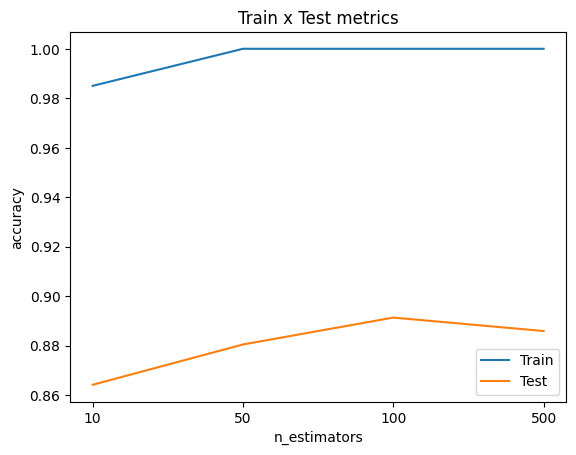

In [18]:
accuracy_list_train = []
accuracy_list_test = []

for n_estimators in n_estimators_list:
    model = RandomForestClassifier(n_estimators=n_estimators,
                                   random_state=RANDOM_STATE).fit(X_train, y_train)
    predictions_train = model.predict(X_train)
    predictions_test = model.predict(X_test)
    accuracy_list_train.append(accuracy_score(predictions_train, y_train))
    accuracy_list_test.append(accuracy_score(predictions_test, y_test))

plt.title('Train x Test metrics')
plt.xlabel('n_estimators')
plt.ylabel('accuracy')
plt.xticks(ticks=range(len(n_estimators_list)), labels=n_estimators_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_test)
plt.legend(['Train', 'Test'])

In [19]:
random_forest_model = RandomForestClassifier(max_depth=8, min_samples_split=10, n_estimators=100,
                                            random_state=RANDOM_STATE).fit(X_train, y_train)

In [20]:
print("Accuracy score on train: ", accuracy_score(random_forest_model.predict(X_train), y_train))
print("Accuracy score on test: ", accuracy_score(random_forest_model.predict(X_test), y_test))

Accuracy score on train:  0.9182561307901907
Accuracy score on test:  0.8804347826086957


### XGBoost

In [21]:
n = int(len(X_train) * 0.8)
X_train_fit, X_train_eval, y_train_fit, y_train_eval = X_train[:n], X_train[n:], y_train[:n], y_train[n:]

In [22]:
xgb_model = XGBClassifier(n_estimators=500, learning_rate=0.1,
                            verbosity=1, early_stopping_rounds=50, random_state=RANDOM_STATE)
xgb_model.fit(X_train_fit, y_train_fit, eval_set=[(X_train_eval, y_train_eval)])

[0]	validation_0-logloss:0.63302
[1]	validation_0-logloss:0.59554
[2]	validation_0-logloss:0.56614
[3]	validation_0-logloss:0.54187
[4]	validation_0-logloss:0.52349
[5]	validation_0-logloss:0.50611
[6]	validation_0-logloss:0.49373
[7]	validation_0-logloss:0.48366
[8]	validation_0-logloss:0.47323
[9]	validation_0-logloss:0.46538
[10]	validation_0-logloss:0.46000
[11]	validation_0-logloss:0.45621
[12]	validation_0-logloss:0.45483
[13]	validation_0-logloss:0.44975
[14]	validation_0-logloss:0.44495
[15]	validation_0-logloss:0.44073
[16]	validation_0-logloss:0.44078
[17]	validation_0-logloss:0.43936
[18]	validation_0-logloss:0.44206
[19]	validation_0-logloss:0.44536
[20]	validation_0-logloss:0.44322
[21]	validation_0-logloss:0.44310
[22]	validation_0-logloss:0.44419
[23]	validation_0-logloss:0.44797
[24]	validation_0-logloss:0.44843
[25]	validation_0-logloss:0.45337
[26]	validation_0-logloss:0.45206
[27]	validation_0-logloss:0.45435
[28]	validation_0-logloss:0.45316
[29]	validation_0-loglos

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=50,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, random_state=55, ...)

In [23]:
xgb_model.best_iteration

17

In [24]:
print("Accuracy score on train: ", accuracy_score(xgb_model.predict(X_train), y_train))
print("Accuracy score on test: ", accuracy_score(xgb_model.predict(X_test), y_test))

Accuracy score on train:  0.9318801089918256
Accuracy score on test:  0.8532608695652174
